In [1]:
!pip install arch

  Using cached statsmodels-0.14.6-cp313-cp313-win_amd64.whl.metadata (9.8 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
   ---------------------------------------- 0.0/929.7 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/929.7 kB ? eta -:--:--
   ---------------------------------------- 929.7/929.7 kB 14.5 MB/s  0:00:00
Using cached statsmodels-0.14.6-cp313-cp313-win_amd64.whl (9.5 MB)
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)

   ---------------------------------------- 0/3 [patsy]
   ---------------------------------------- 0/3 [patsy]
   ---------------------------------------- 0/3 [patsy]
   ---------------------------------------- 0/3 [patsy]
   ------------- -------------------------- 1/3 [statsmodels]
   ------------- -------------------------- 1/3 [statsmodels]
   ------------- -------------------------- 1/3 [statsmodels]
   ------------- -------------------------- 1/3 [statsmodels]
   ------------- ----------------------

In [8]:
import pandas as pd

sp = pd.read_csv(
    r"G:\My Drive\Mathematical Modelling\Aine Code\SP500 (1).csv",
    header=[0,1]
)

sp.columns = [
    c[0] if c[0] == "Date" else c[0]
    for c in sp.columns
]

print(sp.head())

        Price        Close         High          Low         Open  \
0        Date          NaN          NaN          NaN          NaN   
1  2022-01-03  4796.560059  4796.640137  4758.169922  4778.140137   
2  2022-01-04  4793.540039  4818.620117  4774.270020  4804.509766   
3  2022-01-05  4700.580078  4797.700195  4699.439941  4787.990234   
4  2022-01-06  4696.049805  4725.009766  4671.259766  4693.390137   

         Volume  
0           NaN  
1  3.831020e+09  
2  4.683170e+09  
3  4.887960e+09  
4  4.295280e+09  


In [9]:
import numpy as np

sp["Return"] = np.log(sp["Close"] / sp["Close"].shift(1)) * 100
returns = sp["Return"].dropna()

In [10]:
from arch import arch_model

model = arch_model(
    returns,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="normal",
)

result = model.fit(disp="off")

print(result.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1537.93
Distribution:                  Normal   AIC:                           3083.85
Method:            Maximum Likelihood   BIC:                           3103.88
                                        No. Observations:                 1104
Date:                Thu, Jul 09 2026   Df Residuals:                     1103
Time:                        16:01:39   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0770  2.611e-02      2.948  3.194e-03 [2.581e-0

In [12]:
clusters = pd.read_csv(r"G:\My Drive\Mathematical Modelling\Aine Code\cluster_indices.csv")

print(clusters.head())
print(clusters.columns)
print(clusters.shape)

   Unnamed: 0  cluster_1_equal_norm  cluster_1_stability_weighted_norm  \
0  2022-01-01             -3.299895                          -3.259964   
1  2022-01-02             -2.609585                          -2.327482   
2  2022-01-03             -2.008699                          -1.589626   
3  2022-01-04             -1.552572                          -1.045869   
4  2022-01-05             -1.162479                          -0.665018   

   cluster_1_core_equal_norm  cluster_2_equal_norm  \
0                  -2.386681             12.238595   
1                  -1.295609              7.314126   
2                  -0.503573              4.038831   
3                   0.018195              2.318077   
4                   0.246218              2.021688   

   cluster_2_stability_weighted_norm  cluster_2_core_equal_norm  \
0                          13.649931                  13.024344   
1                           8.425543                   9.124356   
2                           4

In [14]:
import numpy as np

# Daily returns (%)
sp["Return"] = np.log(sp["Close"] / sp["Close"].shift(1)) * 100

# Realized volatility (absolute return)
sp["RV"] = sp["Return"].abs()

sp = sp.dropna().reset_index(drop=True)

In [16]:
print(sp.columns.tolist())
print(clusters.columns.tolist()[:5])

['Price', 'Close', 'High', 'Low', 'Open', 'Volume', 'Return', 'RV']
['Date', 'cluster_1_equal_norm', 'cluster_1_stability_weighted_norm', 'cluster_1_core_equal_norm', 'cluster_2_equal_norm']


In [17]:
sp = sp.rename(columns={"Price": "Date"})

sp["Date"] = pd.to_datetime(sp["Date"])

print(sp.columns)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Return', 'RV'], dtype='str')


In [18]:
clusters = pd.read_csv(
    r"G:\My Drive\Mathematical Modelling\Aine Code\cluster_indices.csv"
)

clusters = clusters.rename(columns={"Unnamed: 0": "Date"})
clusters["Date"] = pd.to_datetime(clusters["Date"])

df = sp.merge(clusters, on="Date", how="inner")

print(df.shape)
print(df.head())

(1104, 44)
        Date        Close         High          Low         Open  \
0 2022-01-04  4793.540039  4818.620117  4774.270020  4804.509766   
1 2022-01-05  4700.580078  4797.700195  4699.439941  4787.990234   
2 2022-01-06  4696.049805  4725.009766  4671.259766  4693.390137   
3 2022-01-07  4677.029785  4707.950195  4662.740234  4697.660156   
4 2022-01-10  4670.290039  4673.020020  4582.240234  4655.339844   

         Volume    Return        RV  cluster_1_equal_norm  \
0  4.683170e+09 -0.062982  0.062982             -1.552572   
1  4.887960e+09 -1.958326  1.958326             -1.162479   
2  4.295280e+09 -0.096423  0.096423             -0.928435   
3  4.181510e+09 -0.405844  0.405844             -0.921482   
4  4.511810e+09 -0.144207  0.144207             -0.057456   

   cluster_1_stability_weighted_norm  ...  cluster_3_core_equal_level  \
0                          -1.045869  ...                   49.001840   
1                          -0.665018  ...                   48.8547

In [19]:
cluster_cols = [
    "cluster_1_equal_norm",
    "cluster_2_equal_norm",
    "cluster_3_equal_norm",
    "cluster_4_equal_norm",
    "cluster_5_equal_norm",
    "cluster_6_equal_norm",
]

In [20]:
df["RV_tomorrow"] = df["RV"].shift(-1)
df = df.dropna().reset_index(drop=True)

In [21]:
train_size = int(0.8 * len(df))

train = df.iloc[:train_size].copy()
test = df.iloc[train_size:].copy()

In [22]:
from sklearn.linear_model import LinearRegression

baseline = LinearRegression()

baseline.fit(
    train[["RV"]],
    train["RV_tomorrow"]
)

baseline_pred = baseline.predict(
    test[["RV"]]
)

In [23]:
enhanced = LinearRegression()

enhanced.fit(
    train[["RV"] + cluster_cols],
    train["RV_tomorrow"]
)

enhanced_pred = enhanced.predict(
    test[["RV"] + cluster_cols]
)

In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse_baseline = np.sqrt(
    mean_squared_error(
        test["RV_tomorrow"],
        baseline_pred
    )
)

rmse_enhanced = np.sqrt(
    mean_squared_error(
        test["RV_tomorrow"],
        enhanced_pred
    )
)

mae_baseline = mean_absolute_error(
    test["RV_tomorrow"],
    baseline_pred
)

mae_enhanced = mean_absolute_error(
    test["RV_tomorrow"],
    enhanced_pred
)

print(f"Baseline RMSE : {rmse_baseline:.4f}")
print(f"Enhanced RMSE : {rmse_enhanced:.4f}")
print(f"Baseline MAE  : {mae_baseline:.4f}")
print(f"Enhanced MAE  : {mae_enhanced:.4f}")

Baseline RMSE : 0.5523
Enhanced RMSE : 0.5873
Baseline MAE  : 0.4589
Enhanced MAE  : 0.4471


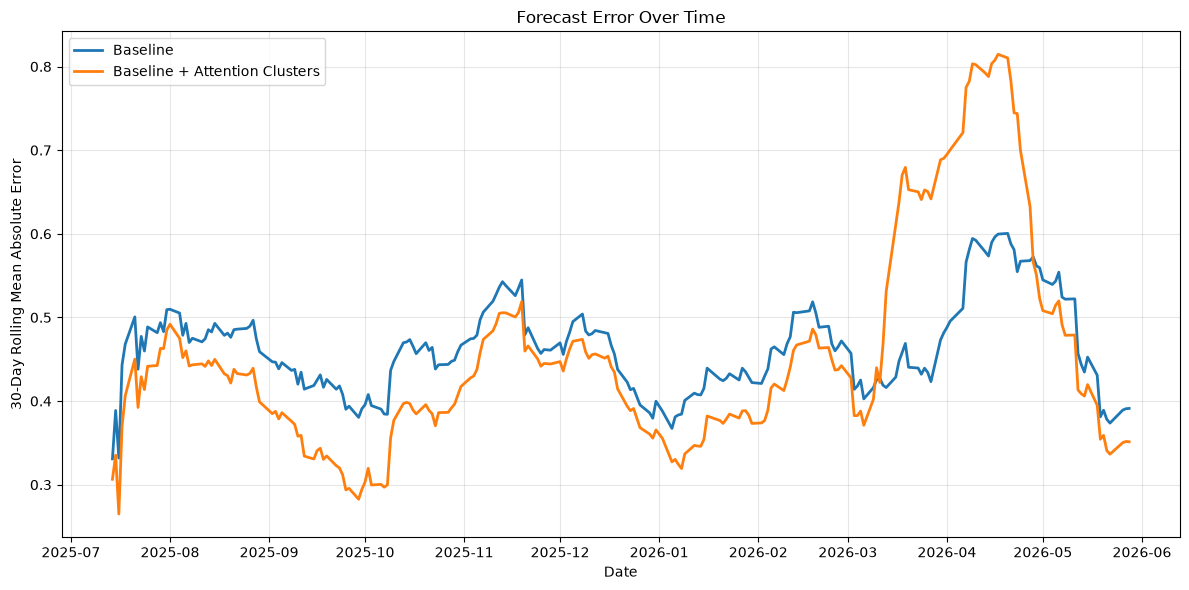

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -----------------------------------------------------------------------------
# Daily absolute prediction errors
# -----------------------------------------------------------------------------

errors = pd.DataFrame({
    "Date": test["Date"].values,
    "Baseline": np.abs(test["RV_tomorrow"] - baseline_pred),
    "Clusters": np.abs(test["RV_tomorrow"] - enhanced_pred),
})

# -----------------------------------------------------------------------------
# 30-day rolling mean
# -----------------------------------------------------------------------------

window = 30

errors["Baseline_Rolling"] = (
    errors["Baseline"]
    .rolling(window, min_periods=1)
    .mean()
)

errors["Clusters_Rolling"] = (
    errors["Clusters"]
    .rolling(window, min_periods=1)
    .mean()
)

# -----------------------------------------------------------------------------
# Plot
# -----------------------------------------------------------------------------

plt.figure(figsize=(12,6))

plt.plot(
    errors["Date"],
    errors["Baseline_Rolling"],
    linewidth=2,
    label="Baseline"
)

plt.plot(
    errors["Date"],
    errors["Clusters_Rolling"],
    linewidth=2,
    label="Baseline + Attention Clusters"
)

plt.ylabel("30-Day Rolling Mean Absolute Error")
plt.xlabel("Date")
plt.title("Forecast Error Over Time")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

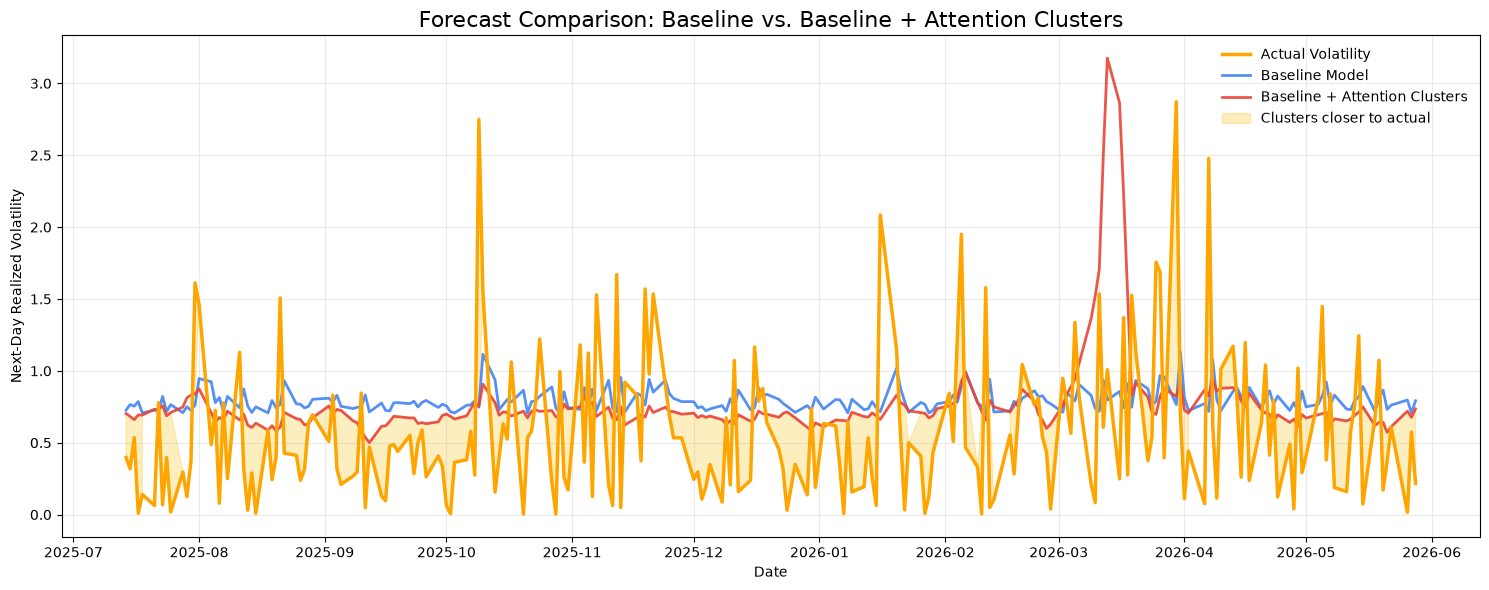

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------------------------------------------------
# Plot dataframe
# -----------------------------------------------------------------------------

plot_df = test.copy()

plot_df["Actual"] = test["RV_tomorrow"].values
plot_df["Baseline"] = baseline_pred
plot_df["Clusters"] = enhanced_pred

# -----------------------------------------------------------------------------
# Google colours
# -----------------------------------------------------------------------------

GOOGLE_BLUE = "#4285F4"
GOOGLE_RED = "#EA4335"
GOOGLE_YELLOW = "#FBBC05"
GOOGLE_GREEN = "#34A853"

# -----------------------------------------------------------------------------
# Which model is closer each day?
# -----------------------------------------------------------------------------

baseline_error = np.abs(plot_df["Actual"] - plot_df["Baseline"])
cluster_error  = np.abs(plot_df["Actual"] - plot_df["Clusters"])

cluster_better = cluster_error < baseline_error

# -----------------------------------------------------------------------------
# Plot
# -----------------------------------------------------------------------------

plt.figure(figsize=(15,6))

# Actual
plt.plot(
    plot_df["Date"],
    plot_df["Actual"],
    color="ORANGE",
    linewidth=2.5,
    label="Actual Volatility",
    zorder=3,
)

# Baseline
plt.plot(
    plot_df["Date"],
    plot_df["Baseline"],
    color=GOOGLE_BLUE,
    linewidth=2,
    alpha=0.9,
    label="Baseline Model",
)

# Cluster model
plt.plot(
    plot_df["Date"],
    plot_df["Clusters"],
    color=GOOGLE_RED,
    linewidth=2,
    alpha=0.9,
    label="Baseline + Attention Clusters",
)

# -----------------------------------------------------------------------------
# Highlight where cluster model is closer
# -----------------------------------------------------------------------------

plt.fill_between(
    plot_df["Date"],
    plot_df["Actual"],
    plot_df["Clusters"],
    where=cluster_better,
    color=GOOGLE_YELLOW,
    alpha=0.25,
    interpolate=True,
    label="Clusters closer to actual",
)

plt.title(
    "Forecast Comparison: Baseline vs. Baseline + Attention Clusters",
    fontsize=16,
)

plt.xlabel("Date")
plt.ylabel("Next-Day Realized Volatility")

plt.grid(alpha=0.25)

plt.legend(frameon=False)

plt.tight_layout()

plt.show()

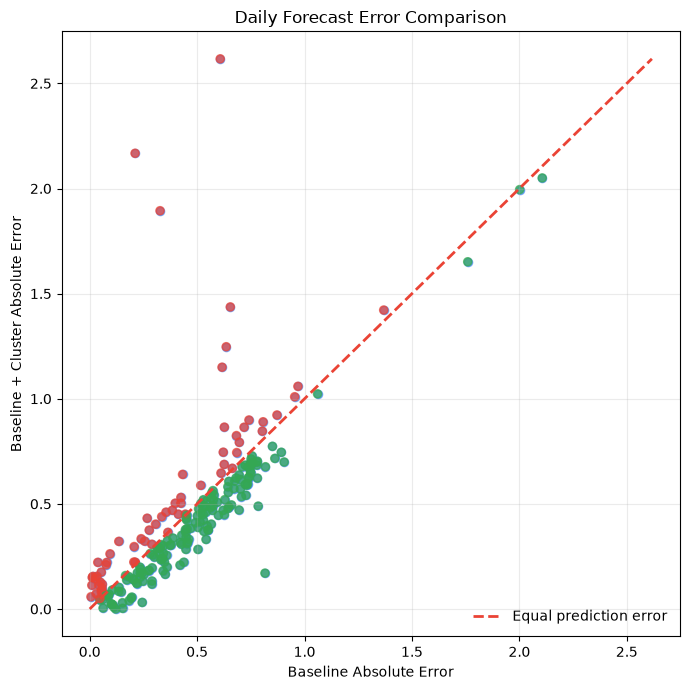

In [30]:
import matplotlib.pyplot as plt
import numpy as np

baseline_error = np.abs(test["RV_tomorrow"] - baseline_pred)
cluster_error  = np.abs(test["RV_tomorrow"] - enhanced_pred)

plt.figure(figsize=(7,7))

plt.scatter(
    baseline_error,
    cluster_error,
    alpha=0.65,
    s=35,
    color="#4285F4"
)

# 45-degree line
mx = max(
    baseline_error.max(),
    cluster_error.max()
)

plt.plot(
    [0,mx],
    [0,mx],
    color="#EA4335",
    linewidth=2,
    linestyle="--",
    label="Equal prediction error"
)

better = cluster_error < baseline_error

colors = np.where(
    better,
    "#34A853",      # Google green
    "#EA4335"       # Google red
)

plt.scatter(
    baseline_error,
    cluster_error,
    c=colors,
    alpha=0.7,
    s=35
)
plt.xlabel("Baseline Absolute Error")
plt.ylabel("Baseline + Cluster Absolute Error")

plt.title("Daily Forecast Error Comparison")

plt.legend(frameon=False)

plt.grid(alpha=0.25)

plt.tight_layout()

plt.show()

In [31]:
error_improvement = baseline_error - cluster_error

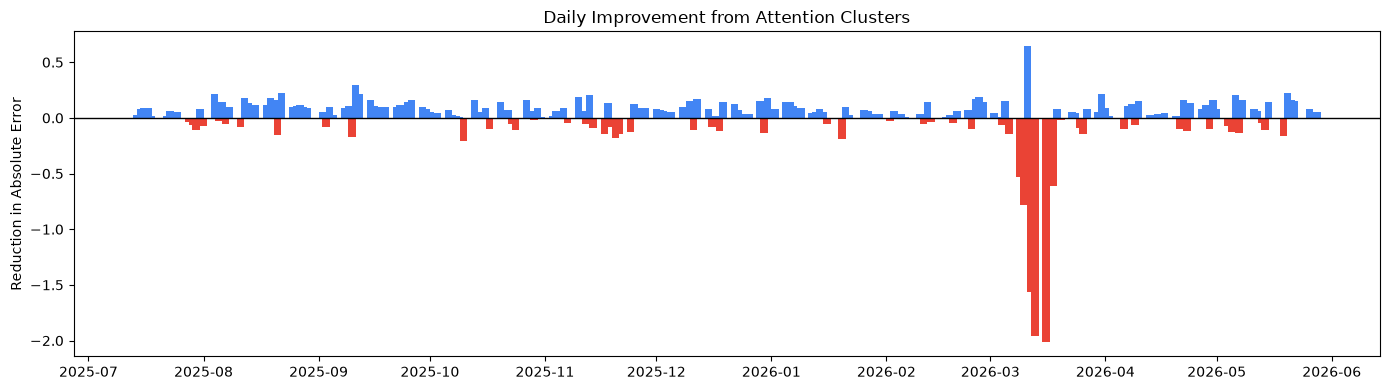

In [35]:
plt.figure(figsize=(14,4))

# Google colours
GOOGLE_BLUE = "#4285F4"
GOOGLE_RED = "#EA4335"

colors = np.where(
    error_improvement > 0,
    "#4285F4",      # green
    "#EA4335"       # red
)

plt.bar(
    test["Date"],
    error_improvement,
    color=colors,
    width=2
)

plt.axhline(
    0,
    color="black",
    linewidth=1
)


plt.ylabel("Reduction in Absolute Error")

plt.title("Daily Improvement from Attention Clusters")

plt.tight_layout()

plt.show()

In [37]:
plot_df = plot_df.iloc[145:190]

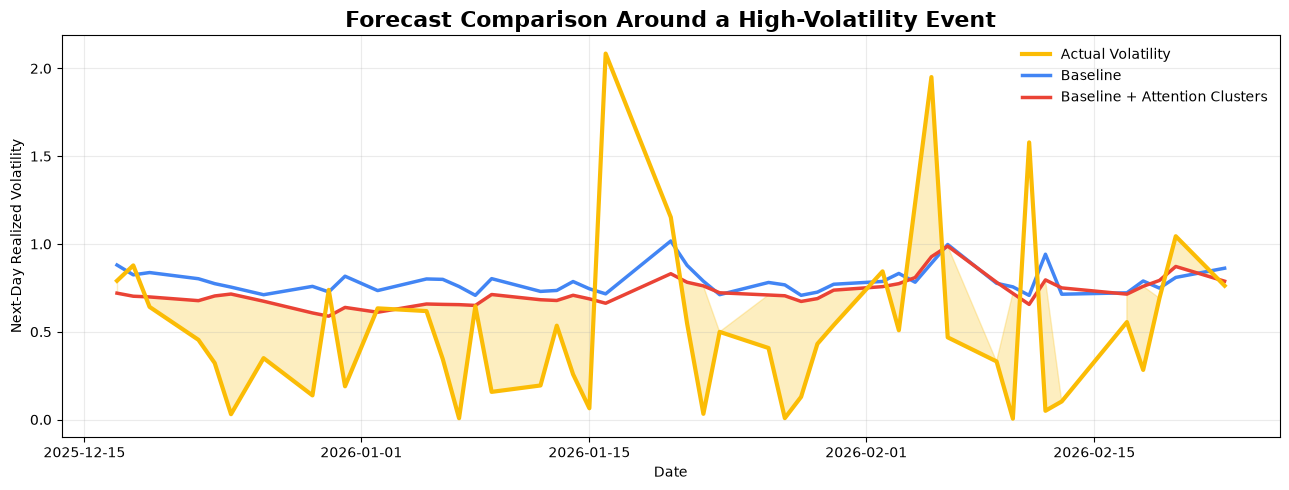

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------------------
# Create plotting dataframe
# ---------------------------------------------------------------------

plot_df = test.copy()

plot_df["Actual"] = test["RV_tomorrow"].values
plot_df["Baseline"] = baseline_pred
plot_df["Clusters"] = enhanced_pred

# ---------------------------------------------------------------------
# Choose window
# ---------------------------------------------------------------------

start = 110
end = 155

plot_df = plot_df.iloc[start:end]

# ---------------------------------------------------------------------
# Google colours
# ---------------------------------------------------------------------

GOOGLE_BLUE = "#4285F4"
GOOGLE_RED = "#EA4335"
GOOGLE_YELLOW = "#FBBC05"

# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------

plt.figure(figsize=(13,5))

plt.plot(
    plot_df["Date"],
    plot_df["Actual"],
    color=GOOGLE_YELLOW,
    linewidth=3,
    label="Actual Volatility",
    zorder=10,
)

plt.plot(
    plot_df["Date"],
    plot_df["Baseline"],
    color=GOOGLE_BLUE,
    linewidth=2.5,
    label="Baseline",
)

plt.plot(
    plot_df["Date"],
    plot_df["Clusters"],
    color=GOOGLE_RED,
    linewidth=2.5,
    label="Baseline + Attention Clusters",
)

# Highlight where clusters are closer to actual
baseline_error = np.abs(plot_df["Actual"] - plot_df["Baseline"])
cluster_error = np.abs(plot_df["Actual"] - plot_df["Clusters"])

plt.fill_between(
    plot_df["Date"],
    plot_df["Actual"],
    plot_df["Clusters"],
    where=(cluster_error < baseline_error),
    color=GOOGLE_YELLOW,
    alpha=0.25,
    interpolate=True,
)

plt.title(
    "Forecast Comparison Around a High-Volatility Event",
    fontsize=16,
    weight="bold"
)

plt.ylabel("Next-Day Realized Volatility")
plt.xlabel("Date")

plt.legend(frameon=False)

plt.grid(alpha=0.25)

plt.tight_layout()

plt.show()

In [42]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

cluster_cols = [
    "cluster_1_equal_norm",
    "cluster_2_equal_norm",
    "cluster_3_equal_norm",
    "cluster_4_equal_norm",
    "cluster_5_equal_norm",
    "cluster_6_equal_norm",
]

baseline_rmse = np.sqrt(
    mean_squared_error(
        test["RV_tomorrow"],
        baseline_pred
    )
)

results = []

for cluster in cluster_cols:

    model = LinearRegression()

    model.fit(
        train[["RV", cluster]],
        train["RV_tomorrow"]
    )

    pred = model.predict(
        test[["RV", cluster]]
    )

    rmse = np.sqrt(
        mean_squared_error(
            test["RV_tomorrow"],
            pred
        )
    )

    results.append(
        {
            "Cluster": cluster.replace("_equal_norm",""),
            "Baseline": baseline_rmse,
            "With Cluster": rmse,
            "Improvement": baseline_rmse-rmse,
        }
    )

results = pd.DataFrame(results)

results

,Cluster,Baseline,With Cluster,Improvement
0,cluster_1,0.552282,0.544163,0.008119
1,cluster_2,0.552282,0.550468,0.001814
2,cluster_3,0.552282,0.564673,-0.012391
3,cluster_4,0.552282,0.572504,-0.020222
4,cluster_5,0.552282,0.553690,-0.001408
5,cluster_6,0.552282,0.552103,0.000179


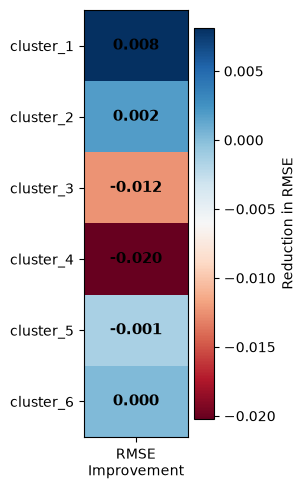

In [43]:
import matplotlib.pyplot as plt

heat = (
    results
    .set_index("Cluster")[["Improvement"]]
)

plt.figure(figsize=(3,5))

plt.imshow(
    heat,
    cmap="RdBu",
    aspect="auto",
)

plt.xticks([0],["RMSE\nImprovement"])

plt.yticks(
    range(len(heat.index)),
    heat.index
)

for i,v in enumerate(heat["Improvement"]):

    plt.text(
        0,
        i,
        f"{v:.3f}",
        ha="center",
        va="center",
        fontsize=11,
        weight="bold",
        color="black",
    )

plt.colorbar(
    label="Reduction in RMSE"
)

plt.tight_layout()

plt.show()

In [44]:
import numpy as np

# Actual values
y = test["RV_tomorrow"].values

# Sum of squared forecast errors
sse_baseline = np.sum((y - baseline_pred)**2)
sse_model = np.sum((y - enhanced_pred)**2)

# Out-of-sample R²
r2_os = 1 - sse_model / sse_baseline

print(f"Out-of-sample R² = {r2_os:.4f}")
print(f"({r2_os*100:.2f}% improvement over the baseline)")

Out-of-sample R² = -0.1308
(-13.08% improvement over the baseline)


In [45]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

cluster_cols = [
    "cluster_1_equal_norm",
    "cluster_2_equal_norm",
    "cluster_3_equal_norm",
    "cluster_4_equal_norm",
    "cluster_5_equal_norm",
    "cluster_6_equal_norm",
]

# ------------------------------------------------------------
# Baseline model
# ------------------------------------------------------------

baseline = LinearRegression()

baseline.fit(
    train[["RV"]],
    train["RV_tomorrow"]
)

baseline_pred = baseline.predict(test[["RV"]])

baseline_rmse = np.sqrt(
    mean_squared_error(
        test["RV_tomorrow"],
        baseline_pred
    )
)

baseline_mae = mean_absolute_error(
    test["RV_tomorrow"],
    baseline_pred
)

print(f"Baseline RMSE = {baseline_rmse:.4f}")
print(f"Baseline MAE  = {baseline_mae:.4f}")
print()

# ------------------------------------------------------------
# One cluster at a time
# ------------------------------------------------------------

results = []

for cluster in cluster_cols:

    model = LinearRegression()

    X_train = train[["RV", cluster]]
    X_test  = test[["RV", cluster]]

    model.fit(
        X_train,
        train["RV_tomorrow"]
    )

    pred = model.predict(X_test)

    rmse = np.sqrt(
        mean_squared_error(
            test["RV_tomorrow"],
            pred
        )
    )

    mae = mean_absolute_error(
        test["RV_tomorrow"],
        pred
    )

    r2_os = 1 - (
        np.sum((test["RV_tomorrow"] - pred) ** 2)
        /
        np.sum((test["RV_tomorrow"] - baseline_pred) ** 2)
    )

    results.append([
        cluster,
        rmse,
        mae,
        r2_os
    ])

results = pd.DataFrame(
    results,
    columns=[
        "Cluster",
        "RMSE",
        "MAE",
        "Out_of_sample_R2"
    ]
)

results["RMSE Change (%)"] = (
    (baseline_rmse - results["RMSE"])
    / baseline_rmse
    * 100
)

results["MAE Change (%)"] = (
    (baseline_mae - results["MAE"])
    / baseline_mae
    * 100
)

print(results.sort_values("RMSE"))

Baseline RMSE = 0.5523
Baseline MAE  = 0.4589

                Cluster      RMSE       MAE  Out_of_sample_R2  \
0  cluster_1_equal_norm  0.544163  0.450651          0.029187   
1  cluster_2_equal_norm  0.550468  0.456487          0.006557   
5  cluster_6_equal_norm  0.552103  0.458359          0.000647   
4  cluster_5_equal_norm  0.553690  0.459486         -0.005106   
2  cluster_3_equal_norm  0.564673  0.439048         -0.045375   
3  cluster_4_equal_norm  0.572504  0.468440         -0.074572   

   RMSE Change (%)  MAE Change (%)  
0         1.470141        1.803420  
1         0.328391        0.531774  
5         0.032350        0.123778  
4        -0.254993       -0.121802  
2        -2.243596        4.331636  
3        -3.661574       -2.072911  


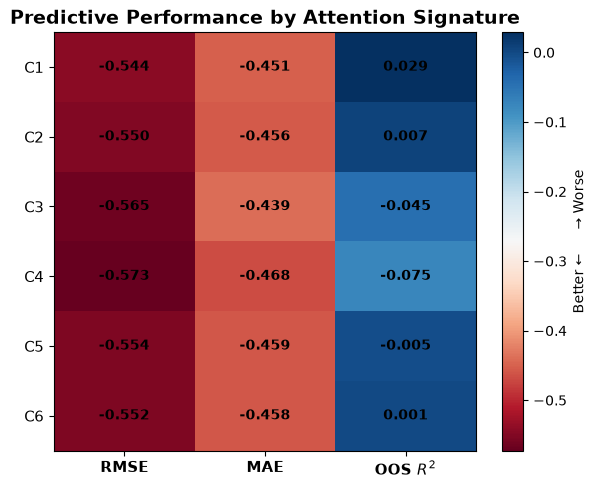

In [46]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# ----------------------------------------------------------
# Prepare heatmap
# ----------------------------------------------------------

heat = results.copy()

heat["Cluster"] = (
    heat["Cluster"]
    .str.replace("_equal_norm", "", regex=False)
    .str.replace("cluster_", "C", regex=False)
)

heat = heat.set_index("Cluster")

# Use improvement metrics so higher is always better
heat["RMSE Improvement"] = -heat["RMSE"]
heat["MAE Improvement"] = -heat["MAE"]

plot_data = heat[
    [
        "RMSE Improvement",
        "MAE Improvement",
        "Out_of_sample_R2",
    ]
]

# ----------------------------------------------------------
# Heatmap
# ----------------------------------------------------------

fig, ax = plt.subplots(figsize=(6,5))

im = ax.imshow(
    plot_data.values,
    cmap="RdBu",          # blue = better, red = worse
    aspect="auto"
)

# Labels
ax.set_xticks(range(plot_data.shape[1]))
ax.set_xticklabels(
    ["RMSE", "MAE", "OOS $R^2$"],
    fontsize=11,
    fontweight="bold"
)

ax.set_yticks(range(plot_data.shape[0]))
ax.set_yticklabels(
    plot_data.index,
    fontsize=11
)

# Numbers inside cells
for i in range(plot_data.shape[0]):
    for j in range(plot_data.shape[1]):
        ax.text(
            j,
            i,
            f"{plot_data.iloc[i,j]:.3f}",
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            color="black"
        )

cbar = plt.colorbar(im)
cbar.set_label("Better ←      → Worse")

plt.title(
    "Predictive Performance by Attention Signature",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

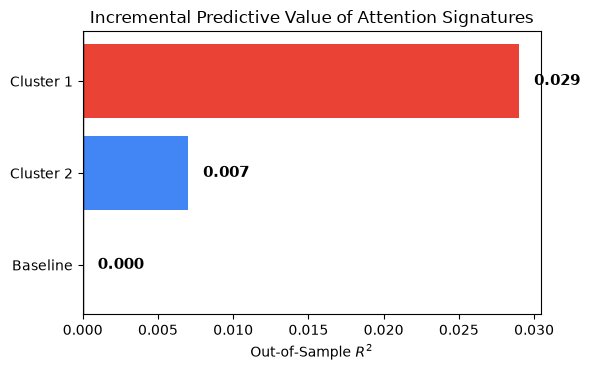

In [47]:
import matplotlib.pyplot as plt

clusters = ["Baseline", "Cluster 2", "Cluster 1"]
oos = [0.000, 0.007, 0.029]

colors = [
    "#9E9E9E",   # baseline
    "#4285F4",   # Google blue
    "#EA4335",   # Google red
]

plt.figure(figsize=(6,3.8))

bars = plt.barh(
    clusters,
    oos,
    color=colors
)

for bar, value in zip(bars, oos):
    plt.text(
        value + 0.001,
        bar.get_y() + bar.get_height()/2,
        f"{value:.3f}",
        va="center",
        fontsize=11,
        weight="bold"
    )

plt.axvline(0, color="black", linewidth=1)

plt.xlabel("Out-of-Sample $R^2$")
plt.title("Incremental Predictive Value of Attention Signatures")

plt.tight_layout()
plt.show()

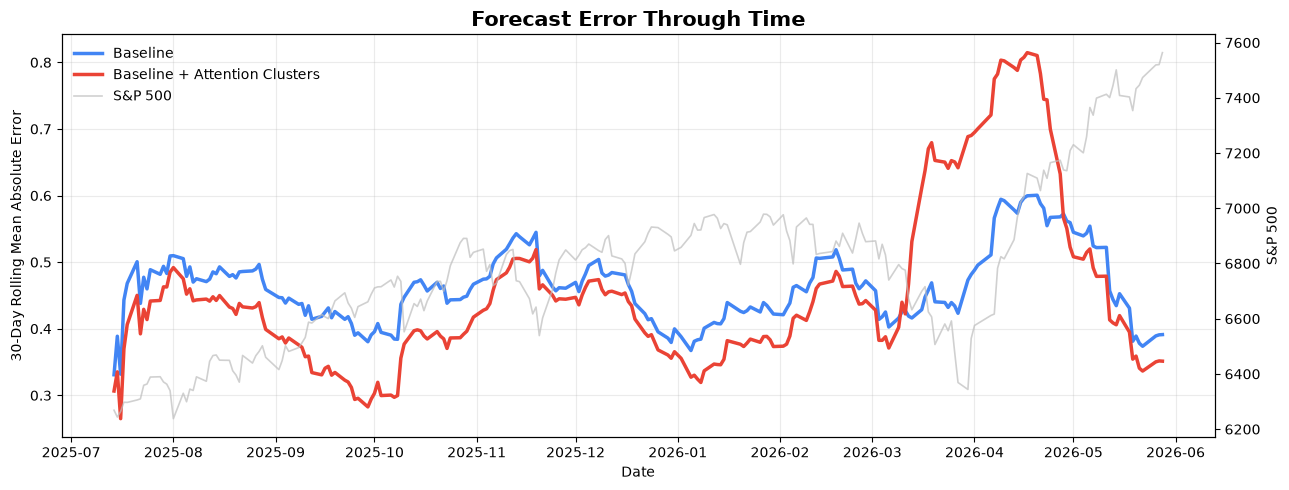

In [48]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Error dataframe
# ------------------------------------------------------------

errors = pd.DataFrame({
    "Date": test["Date"].values,
    "Baseline": np.abs(test["RV_tomorrow"] - baseline_pred),
    "Clusters": np.abs(test["RV_tomorrow"] - enhanced_pred),
})

window = 30

errors["Baseline"] = (
    errors["Baseline"]
    .rolling(window, min_periods=1)
    .mean()
)

errors["Clusters"] = (
    errors["Clusters"]
    .rolling(window, min_periods=1)
    .mean()
)

# ------------------------------------------------------------
# Merge in S&P price
# ------------------------------------------------------------

plot_df = errors.merge(
    sp[["Date", "Close"]],
    on="Date",
    how="left"
)

# ------------------------------------------------------------
# Google colours
# ------------------------------------------------------------

GOOGLE_BLUE = "#4285F4"
GOOGLE_RED = "#EA4335"
GREY = "#BDBDBD"

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(13,5))

# Error lines
ax1.plot(
    plot_df["Date"],
    plot_df["Baseline"],
    color=GOOGLE_BLUE,
    linewidth=2.5,
    label="Baseline",
)

ax1.plot(
    plot_df["Date"],
    plot_df["Clusters"],
    color=GOOGLE_RED,
    linewidth=2.5,
    label="Baseline + Attention Clusters",
)

ax1.set_ylabel("30-Day Rolling Mean Absolute Error")
ax1.set_xlabel("Date")

# ------------------------------------------------------------
# Secondary axis for S&P 500
# ------------------------------------------------------------

ax2 = ax1.twinx()

ax2.plot(
    plot_df["Date"],
    plot_df["Close"],
    color=GREY,
    linewidth=1.2,
    alpha=0.7,
    linestyle="-",
    label="S&P 500"
)

ax2.set_ylabel("S&P 500")

# ------------------------------------------------------------
# Combine legends
# ------------------------------------------------------------

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left",
    frameon=False
)

plt.title(
    "Forecast Error Through Time",
    fontsize=15,
    weight="bold"
)

ax1.grid(alpha=0.25)

plt.tight_layout()

plt.show()

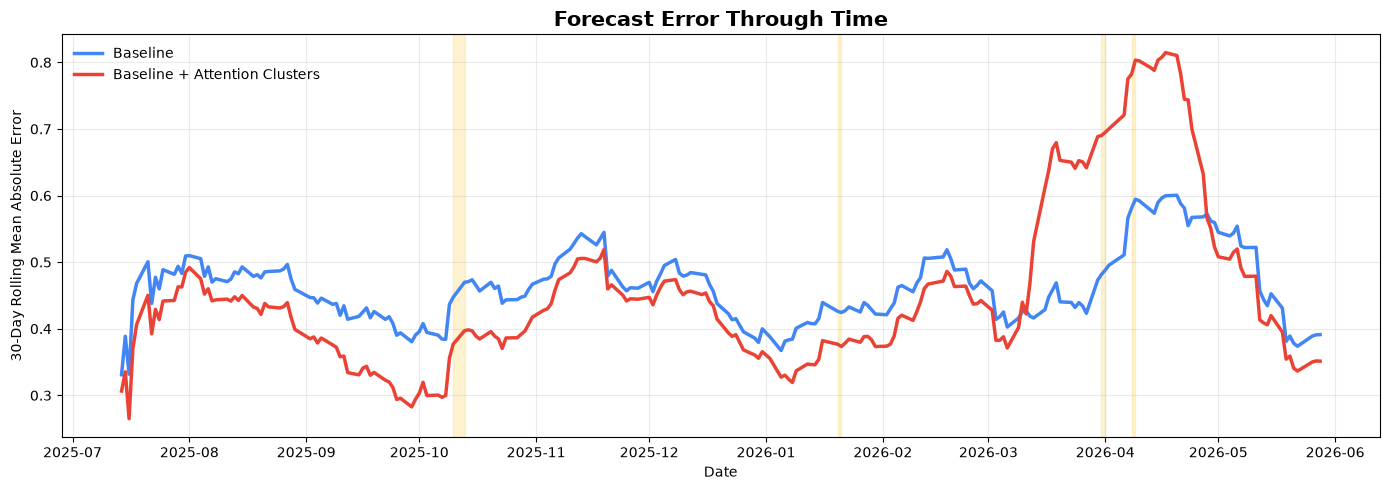

In [49]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Rolling forecast errors
# ------------------------------------------------------------

errors = pd.DataFrame({
    "Date": test["Date"].values,
    "Baseline": np.abs(test["RV_tomorrow"] - baseline_pred),
    "Clusters": np.abs(test["RV_tomorrow"] - enhanced_pred),
})

window = 30

errors["Baseline"] = (
    errors["Baseline"]
    .rolling(window, min_periods=1)
    .mean()
)

errors["Clusters"] = (
    errors["Clusters"]
    .rolling(window, min_periods=1)
    .mean()
)

# ------------------------------------------------------------
# Merge S&P returns
# ------------------------------------------------------------

plot_df = errors.merge(
    sp[["Date", "Return"]],
    on="Date",
    how="left"
)

# Large market moves (>2%)
plot_df["Stress"] = plot_df["Return"].abs() > 2

# ------------------------------------------------------------
# Google colours
# ------------------------------------------------------------

GOOGLE_BLUE = "#4285F4"
GOOGLE_RED = "#EA4335"
GOOGLE_YELLOW = "#FBBC05"

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14,5))

ax.plot(
    plot_df["Date"],
    plot_df["Baseline"],
    color=GOOGLE_BLUE,
    linewidth=2.5,
    label="Baseline",
)

ax.plot(
    plot_df["Date"],
    plot_df["Clusters"],
    color=GOOGLE_RED,
    linewidth=2.5,
    label="Baseline + Attention Clusters",
)

# ------------------------------------------------------------
# Shade market stress periods
# ------------------------------------------------------------

stress = plot_df["Stress"]

start = None

for i in range(len(plot_df)):

    if stress.iloc[i] and start is None:
        start = plot_df["Date"].iloc[i]

    if (not stress.iloc[i] or i == len(plot_df)-1) and start is not None:

        end = plot_df["Date"].iloc[i]

        ax.axvspan(
            start,
            end,
            color=GOOGLE_YELLOW,
            alpha=0.18
        )

        start = None

# ------------------------------------------------------------

ax.set_title(
    "Forecast Error Through Time",
    fontsize=15,
    weight="bold"
)

ax.set_ylabel("30-Day Rolling Mean Absolute Error")
ax.set_xlabel("Date")

ax.legend(frameon=False)

ax.grid(alpha=0.25)

plt.tight_layout()

plt.show()

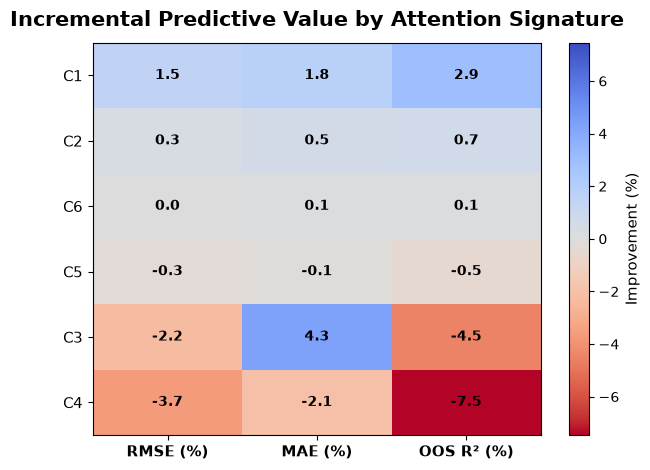

In [51]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Build table
# ------------------------------------------------------------

heat = results.copy()

heat["Cluster"] = (
    heat["Cluster"]
    .str.replace("_equal_norm", "", regex=False)
    .str.replace("cluster_", "C", regex=False)
)

# Percentage improvements
heat["RMSE (%)"] = (
    (baseline_rmse - heat["RMSE"])
    / baseline_rmse
    * 100
)

heat["MAE (%)"] = (
    (baseline_mae - heat["MAE"])
    / baseline_mae
    * 100
)

heat["OOS R² (%)"] = heat["Out_of_sample_R2"] * 100

heat = (
    heat[
        ["Cluster","RMSE (%)","MAE (%)","OOS R² (%)"]
    ]
    .set_index("Cluster")
    .sort_values("OOS R² (%)", ascending=False)
)

# ------------------------------------------------------------
# Symmetric colour scale around zero
# ------------------------------------------------------------

v = np.max(np.abs(heat.values))

norm = colors.TwoSlopeNorm(
    vmin=-v,
    vcenter=0,
    vmax=v
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6.2,4.8))

im = ax.imshow(
    heat.values,
    cmap="coolwarm_r",      # much softer than RdBu
    norm=norm,
    aspect="auto"
)

# Axis labels

ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(
    heat.columns,
    fontsize=11,
    fontweight="bold"
)

ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(
    heat.index,
    fontsize=11
)

# Cell values

for i in range(len(heat.index)):
    for j in range(len(heat.columns)):

        value = heat.iloc[i,j]

        ax.text(
            j,
            i,
            f"{value:.1f}",
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            color="black"
        )

# Colour bar

cbar = plt.colorbar(im)

cbar.set_label(
    "Improvement (%)",
    fontsize=11
)

plt.title(
    "Incremental Predictive Value by Attention Signature",
    fontsize=15,
    fontweight="bold",
    pad=12
)

plt.tight_layout()

plt.show()